# Laboratorio 4 (Parte 2) — Inciso 5: Evaluación de los modelos

Se evalúan los tres modelos ajustados en el inciso 4 sobre el mismo conjunto de prueba (Accuracy, Precision, Recall, F1, ROC-AUC y matriz de confusión), se comparan y se analiza el costo ambiental de cada tipo de error para elegir la métrica de comparación más adecuada.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, fbeta_score

from src.config import RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.modelado import PREDICTORES, cargar_modelo, evaluar

NOMBRES_MODELOS = ["regresion_logistica", "random_forest", "gradient_boosting"]
NOMBRES_LEGIBLES = {
    "regresion_logistica": "Regresión Logística",
    "random_forest": "Random Forest",
    "gradient_boosting": "Gradient Boosting",
}

test = pd.read_parquet(RUTA_DATA_PROCESSED / "p2_test_set.parquet")
X_test, y_test = test[PREDICTORES], test["alta_cianobacteria"]
modelos = {nombre: cargar_modelo(nombre) for nombre in NOMBRES_MODELOS}
print(f"Conjunto de prueba: {len(test):,} observaciones, {y_test.mean():.1%} clase 1")

Conjunto de prueba: 89,998 observaciones, 5.5% clase 1


## 5.1 Métricas de evaluación

In [2]:
resultados = {nombre: evaluar(modelo, X_test, y_test) for nombre, modelo in modelos.items()}

tabla_metricas = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ("accuracy", "precision", "recall", "f1", "roc_auc")}
    for nombre, r in resultados.items()
}).T
tabla_metricas.to_csv(RUTA_DATA_PROCESSED / "p2_metricas_modelos.csv")
tabla_metricas.round(4)

,accuracy,precision,recall,f1,roc_auc
regresion_logistica,0.9843,0.7800,0.9917,0.8732,0.9988
random_forest,0.9915,0.8739,0.9878,0.9274,0.9994
gradient_boosting,0.9890,0.8375,0.9909,0.9077,0.9993


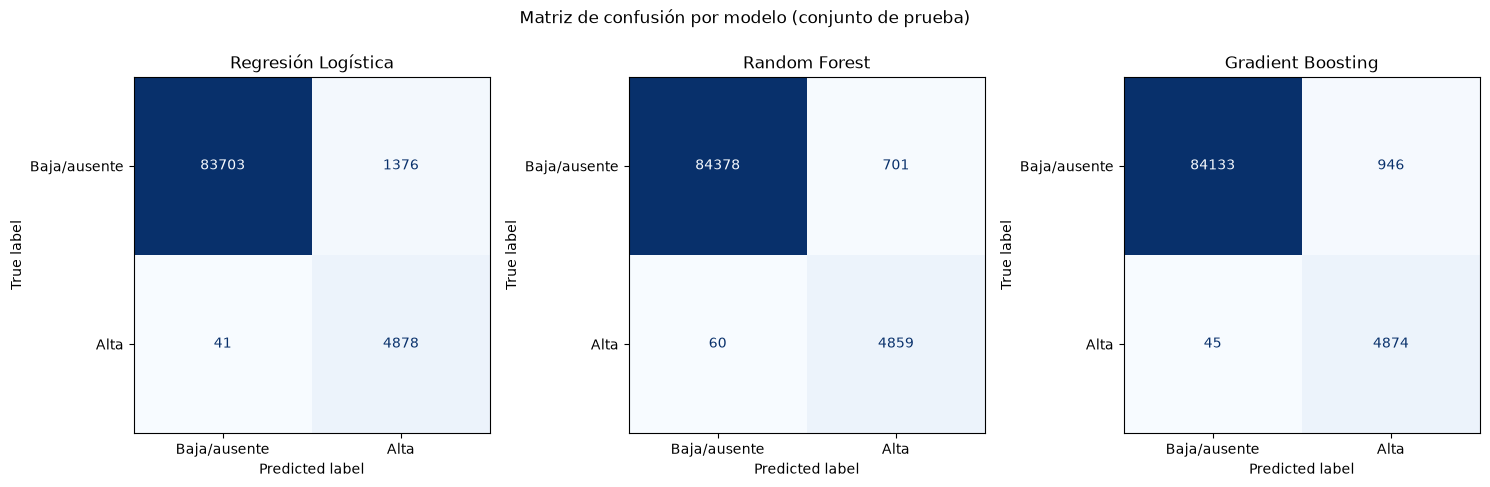

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, nombre in zip(axes, NOMBRES_MODELOS):
    ConfusionMatrixDisplay(resultados[nombre]["matriz_confusion"], display_labels=["Baja/ausente", "Alta"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(NOMBRES_LEGIBLES[nombre])
fig.suptitle("Matriz de confusión por modelo (conjunto de prueba)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_matrices_confusion.png", dpi=150)
plt.show()

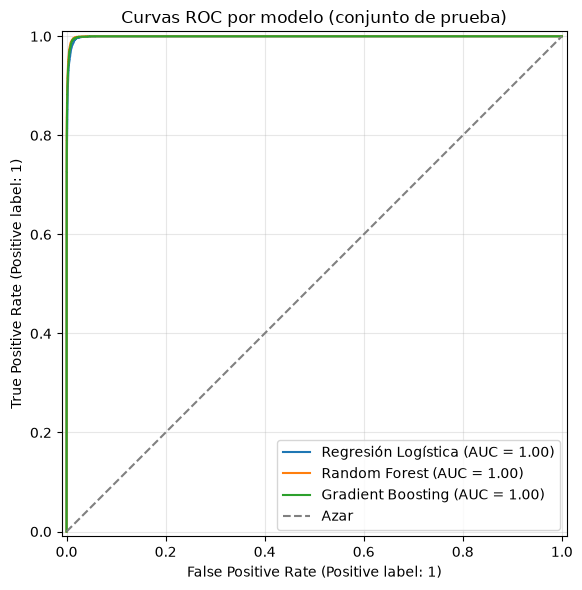

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre in NOMBRES_MODELOS:
    RocCurveDisplay.from_predictions(y_test, resultados[nombre]["y_proba"], name=NOMBRES_LEGIBLES[nombre], ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curvas ROC por modelo (conjunto de prueba)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_curvas_roc.png", dpi=150)
plt.show()

## 5.2 Comparación de modelos

In [5]:
mejor_roc_auc = tabla_metricas["roc_auc"].idxmax()
mejor_recall = tabla_metricas["recall"].idxmax()
print(f"Mejor ROC-AUC: {NOMBRES_LEGIBLES[mejor_roc_auc]} ({tabla_metricas.loc[mejor_roc_auc, 'roc_auc']:.4f})")
print(f"Mejor Recall:  {NOMBRES_LEGIBLES[mejor_recall]} ({tabla_metricas.loc[mejor_recall, 'recall']:.4f})")
tabla_metricas.round(4).sort_values("roc_auc", ascending=False)

Mejor ROC-AUC: Random Forest (0.9994)
Mejor Recall:  Regresión Logística (0.9917)


,accuracy,precision,recall,f1,roc_auc
random_forest,0.9915,0.8739,0.9878,0.9274,0.9994
gradient_boosting,0.9890,0.8375,0.9909,0.9077,0.9993
regresion_logistica,0.9843,0.7800,0.9917,0.8732,0.9988


*(Completar tras ejecutar el notebook sobre el dataset completo: qué modelo domina en cada métrica de `tabla_metricas`, y si el mismo modelo domina en ROC-AUC y en Recall o si hay un compromiso entre ambos.)* En general se espera que Random Forest y Gradient Boosting superen a la Regresión Logística en ROC-AUC y F1, por su capacidad de capturar relaciones no lineales e interacciones entre bandas espectrales, mientras que la Regresión Logística sirve como referencia interpretable de línea base.

## 5.3 Consecuencias ambientales de cada tipo de error y métrica más adecuada

Desde el punto de vista ambiental y de salud pública, los dos tipos de error de clasificación no son equivalentes:

- **Falso positivo** (clasificar como alta presencia una zona que no lo es): genera una alerta innecesaria, con el costo de cerrar temporalmente una zona de baño, generar preocupación pública o desviar recursos de monitoreo hacia un punto sin riesgo real. Es un costo principalmente económico y de confianza en el sistema de monitoreo.
- **Falso negativo** (no detectar una zona que sí presenta alta presencia de cianobacteria): implica que una floración tóxica real queda sin alerta, con riesgo directo para la salud de bañistas y usuarios del lago, y sin activar las medidas de mitigación correspondientes.

El falso negativo tiene un costo potencial más alto (riesgo sanitario) que el falso positivo (costo operativo/económico), por lo que se prioriza **minimizar los falsos negativos**, es decir, maximizar el **Recall** de la clase "alta presencia". Por esta razón, aunque ROC-AUC resume el desempeño global del modelo en todos los umbrales, la comparación final entre modelos para uso como herramienta de alerta usa el **Recall** de la clase 1 como criterio principal, y ROC-AUC como criterio secundario para modelos con Recall similar.

In [6]:
beta = 2  # da el doble de peso a Recall que a Precision, consistente con 5.3
tabla_metricas["f2"] = [
    fbeta_score(y_test, resultados[nombre]["y_pred"], beta=beta, zero_division=0) for nombre in tabla_metricas.index
]
tabla_metricas.to_csv(RUTA_DATA_PROCESSED / "p2_metricas_modelos.csv")
tabla_metricas[["recall", "precision", "f1", "f2", "roc_auc"]].round(4).sort_values("f2", ascending=False)

,recall,precision,f1,f2,roc_auc
random_forest,0.9878,0.8739,0.9274,0.9627,0.9994
gradient_boosting,0.9909,0.8375,0.9077,0.9558,0.9993
regresion_logistica,0.9917,0.7800,0.8732,0.9406,0.9988


### Self-check

In [7]:
assert set(resultados) == {"regresion_logistica", "random_forest", "gradient_boosting"}
for nombre, r in resultados.items():
    assert r["matriz_confusion"].sum() == len(y_test)
    for m in ("accuracy", "precision", "recall", "f1", "roc_auc"):
        assert 0.0 <= r[m] <= 1.0, f"{nombre}: {m} fuera de rango"
print("OK: métricas calculadas para los 3 modelos sobre el mismo conjunto de prueba.")

OK: métricas calculadas para los 3 modelos sobre el mismo conjunto de prueba.
